# Autoencoder — AE

**Input:** `nominal_scaled`, `kat_*_scaled` (10 OHE columns), `hour_sin_scaled`, `hour_cos_scaled`, `nominal_z_user_kat_scaled` — loaded from `preprocessing_meta.pkl`

In [82]:
import os
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.losses import Loss
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

tf.random.set_seed(42)
np.random.seed(42)

DATA_DIR  = '../../../data/ae_3pct'
MODEL_DIR = '../../../model/ae_3pct'
os.makedirs(MODEL_DIR, exist_ok=True)

## Load Data

In [83]:
meta = joblib.load(f'{MODEL_DIR}/preprocessing_meta.pkl')
SCALED_COLS = meta['scaled_cols']

df_train     = pd.read_csv(f'{DATA_DIR}/pre_train.csv')
df_threshold = pd.read_csv(f'{DATA_DIR}/pre_threshold.csv', parse_dates=['timestamp'])

X_train = df_train[SCALED_COLS].values.astype(np.float32)
INPUT_DIM = X_train.shape[1]

print(f"X_train   : {X_train.shape}")
print(f"threshold : {df_threshold.shape}")
print(f"Input dim : {INPUT_DIM}")

X_train   : (178055, 14)
threshold : (45512, 35)
Input dim : 14


## Arsitektur

```
Input(14) → Dense(32) → Dense(16) → Dense(8) [bottleneck]
          → Dense(16)  → Dense(32) → Dense(14)
```

**Loss: Weighted MAE**

In [84]:
FEATURE_WEIGHTS = meta['feature_weights']

class WeightedMAELoss(Loss):
    def __init__(self, feature_weights, name='weighted_mae', **kwargs):
        super().__init__(name=name, **kwargs)
        self.feature_weights = list(feature_weights)
        self._w = tf.constant(feature_weights, dtype=tf.float32)

    def call(self, y_true, y_pred):
        per_feature = tf.abs(y_true - y_pred) * self._w
        return tf.reduce_mean(tf.reduce_sum(per_feature, axis=1))

    def get_config(self):
        return {**super().get_config(), 'feature_weights': self.feature_weights}

def build_autoencoder(input_dim):
    inp     = Input(shape=(input_dim,))
    x       = Dense(64, activation='relu')(inp)   
    x       = Dense(32, activation='relu')(x)
    encoded = Dense(12, activation='relu')(x)    
    x       = Dense(32, activation='relu')(encoded)
    x       = Dense(64, activation='relu')(x)
    out     = Dense(input_dim, activation='linear')(x)
    model   = Model(inputs=inp, outputs=out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss=WeightedMAELoss(FEATURE_WEIGHTS)
    )
    return model

autoencoder = build_autoencoder(INPUT_DIM)
autoencoder.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 64)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 12)             │           396 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 32)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 14)             │           910 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,874 (26.85 KB)

 Trainable params: 6,874 (26.85 KB)

 Non-trainable params: 0 (0.00 B)

## Training

In [85]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,    
        min_lr=1e-4,     
        verbose=1
    ),
    ModelCheckpoint(f'{MODEL_DIR}/autoencoder.keras', monitor='val_loss', save_best_only=True, verbose=0),
]

history = autoencoder.fit(
    X_train, X_train,
    epochs=150,
    batch_size=128,
    validation_split=0.15,
    shuffle=True,
    callbacks=callbacks,
    verbose=1,
)

print(f"Best val_loss : {min(history.history['val_loss']):.6f}")

Epoch 1/150
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 2s 486us/step - loss: 1.0309 - val_loss: 0.6050 - learning_rate: 0.0010
Epoch 2/150
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 1s 429us/step - loss: 0.5365 - val_loss: 0.3460 - learning_rate: 0.0010
Epoch 3/150
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 1s 425us/step - loss: 0.3921 - val_loss: 0.3419 - learning_rate: 0.0010
Epoch 4/150
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 1s 428us/step - loss: 0.3693 - val_loss: 0.3192 - learning_rate: 0.0010
Epoch 5/150
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 1s 429us/step - loss: 0.3592 - val_loss: 0.3182 - learning_rate: 0.0010
Epoch 6/150
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 1s 427us/step - loss: 0.3489 - val_loss: 0.2895 - learning_rate: 0.0010
Epoch 7/150
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 1s 429us/step - loss: 0.3028 - val_loss: 0.2556 - learning_rate: 0.0010
Epoch 8/150
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 1s 423us/step - loss: 0.2804 - val_loss: 0.2405 - learning_rate: 0.0010
Epoch 9/150
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 1s 420us/step - loss: 0.2754 - val_lo

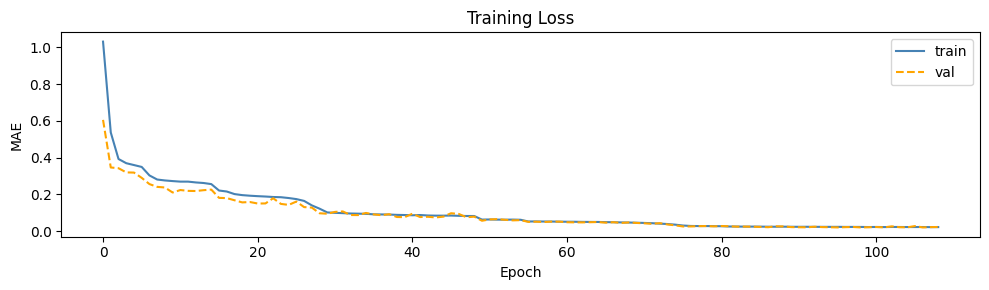

In [86]:
plt.figure(figsize=(10, 3))
plt.plot(history.history['loss'],     label='train', color='steelblue')
plt.plot(history.history['val_loss'], label='val',   color='orange', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Training Loss')
plt.legend()
plt.tight_layout()
plt.show()

## Threshold per User per Kategori

Fit pada **threshold data** (Bulan 5 — normal). Threshold = persentil 95 MAE per `(id_user, kategori_detail)`.

In [87]:
autoencoder = tf.keras.models.load_model(
    f'{MODEL_DIR}/autoencoder.keras', compile=False)

X_thr     = df_threshold[SCALED_COLS].values.astype(np.float32)
X_thr_rec = autoencoder.predict(X_thr, verbose=0)
mae_thr   = np.abs(X_thr - X_thr_rec).mean(axis=1)

df_threshold        = df_threshold.copy()
df_threshold['mae'] = mae_thr

threshold_user_kat = (
    df_threshold.groupby(['id_user', 'kategori_detail'])['mae']
    .quantile(0.90)
    .rename('threshold')
    .reset_index())

threshold_kat = (
    df_threshold.groupby('kategori_detail')['mae']
    .quantile(0.90)
    .rename('threshold')
    .to_dict())

print(f"User×kategori combinations : {len(threshold_user_kat)}")
print(f"Kategori fallback          : {len(threshold_kat)}")
print(threshold_user_kat.head(10).to_string(index=False))

User×kategori combinations : 3892
Kategori fallback          : 10
id_user             kategori_detail  threshold
USR-001           F&B dan Nongkrong   0.002308
USR-001 Groceries & Kebutuhan Pokok   0.003064
USR-001         Hiburan & Langganan   0.001781
USR-001       Investasi & Finansial   0.011944
USR-001  Kesehatan & Perawatan Diri   0.004506
USR-001          Tagihan & Utilitas   0.012063
USR-001                Transfer P2P   0.002482
USR-001                Transportasi   0.004884
USR-002           F&B dan Nongkrong   0.005540
USR-002 Groceries & Kebutuhan Pokok   0.003896


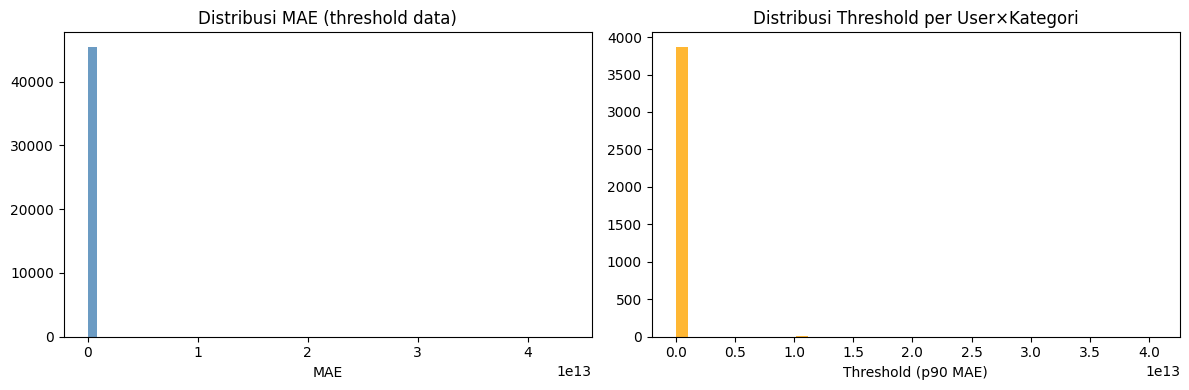

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(mae_thr, bins=50, color='steelblue', alpha=0.8)
axes[0].set_title('Distribusi MAE (threshold data)')
axes[0].set_xlabel('MAE')

axes[1].hist(threshold_user_kat['threshold'], bins=40, color='orange', alpha=0.8)
axes[1].set_title('Distribusi Threshold per User×Kategori')
axes[1].set_xlabel('Threshold (p90 MAE)')

plt.tight_layout()
plt.show()

## Validasi pada Test Data

Evaluasi model pada fase test menggunakan kondisi dua syarat:
prediksi anomali hanya aktif jika **MAE > threshold** sekaligus **nominal > mean_nominal** user di kategori tersebut (baseline dari threshold data).

              precision    recall  f1-score   support

      Normal       1.00      0.89      0.94     42608
     Anomali       0.20      0.88      0.32      1317

    accuracy                           0.89     43925
   macro avg       0.60      0.88      0.63     43925
weighted avg       0.97      0.89      0.92     43925



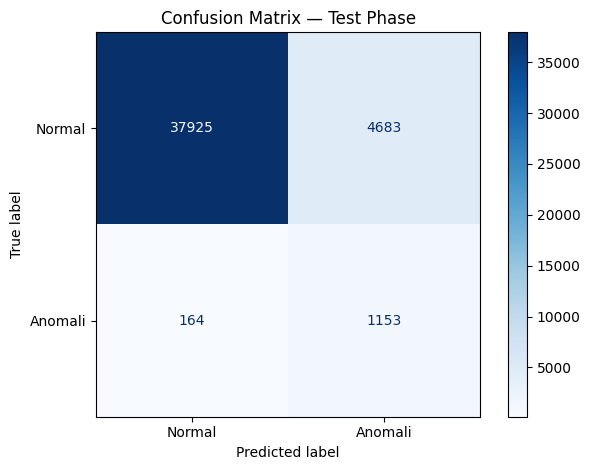

In [89]:
df_test_val = pd.read_csv(f'{DATA_DIR}/pre_test.csv', parse_dates=['timestamp'])
X_test_val  = df_test_val[SCALED_COLS].values.astype(np.float32)
X_test_rec  = autoencoder.predict(X_test_val, verbose=0)
mae_test    = np.abs(X_test_val - X_test_rec).mean(axis=1)

df_test_val['mae'] = mae_test

threshold_dict = {
    (row['id_user'], row['kategori_detail']): row['threshold']
    for _, row in threshold_user_kat.iterrows()}

_median_thr = float(np.median(list(threshold_dict.values())))

df_test_val['threshold'] = df_test_val.apply(
    lambda r: threshold_dict.get(
        (r['id_user'], r['kategori_detail']),
        threshold_kat.get(r['kategori_detail'], _median_thr)
    ), axis=1)

user_cat_mean_nominal = (
    df_threshold.groupby(['id_user', 'kategori_detail'])['nominal']
    .mean()
    .rename('mean_nominal')
    .reset_index())

cat_mean_nominal = (
    df_threshold.groupby('kategori_detail')['nominal']
    .mean()
    .to_dict())

df_test_val = df_test_val.merge(user_cat_mean_nominal, on=['id_user', 'kategori_detail'], how='left')

df_test_val['mean_nominal'] = df_test_val['mean_nominal'].fillna(
    df_test_val['kategori_detail'].map(cat_mean_nominal))

df_test_val['pred_anomali'] = (
    (df_test_val['mae'] > df_test_val['threshold']) &
    (df_test_val['nominal'] > df_test_val['mean_nominal'])).astype(int)

y_true_val = df_test_val['label_anomali'].values.astype(int)

print(classification_report(y_true_val, df_test_val['pred_anomali'],
                             target_names=['Normal', 'Anomali']))

cm = confusion_matrix(y_true_val, df_test_val['pred_anomali'])
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Anomali'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Test Phase')
plt.tight_layout()
plt.show()

## Simpan

In [90]:
threshold_dict = {
    (row['id_user'], row['kategori_detail']): row['threshold']
    for _, row in threshold_user_kat.iterrows()}

joblib.dump({
    'threshold_user_kat' : threshold_dict,
    'threshold_kat'      : threshold_kat,
    'scaled_cols'        : SCALED_COLS,
}, f'{MODEL_DIR}/model_meta.pkl')

print(f"autoencoder.keras  → {MODEL_DIR}")
print(f"model_meta.pkl     → {MODEL_DIR}")

autoencoder.keras  → ../../../model/ae_3pct
model_meta.pkl     → ../../../model/ae_3pct
